# Exploratory Data Analysis (EDA)

In [1]:
import pandas as pd

df = pd.read_csv("../data/cleaned_retail.csv")

In [2]:
# total revenue
total_revenue = df["Revenue"].sum()

print(f"Total Revenue: {total_revenue:,.2f}")

Total Revenue: 8,798,233.74


In [3]:
# total orders
total_orders = df["Invoice"].nunique()

print("Total Orders:", total_orders)

Total Orders: 19213


In [4]:
# total customers
total_customers = df["Customer ID"].nunique()

print("Total Customers:", total_customers)

Total Customers: 4312


In [5]:
# average order value
aov = total_revenue / total_orders

print(f"Average Order Value: {aov:.2f}")

Average Order Value: 457.93


# Business KPI Summary

- Total Revenue: 8,798,233.74
- Total Orders: 19,213
- Total Customers: 4,312
- Average Order Value: 457.93

Key Observation:
The company generated approximately 8.8 million in revenue from over 19,000 orders, indicating strong customer purchasing activity.

In [6]:
# monthly trend sales
monthly_sales = (
    df.groupby("Month")["Revenue"]
      .sum()
      .reset_index()
)

monthly_sales

,Month,Revenue
0,1,555802.672
1,2,504558.956
2,3,696978.471
3,4,591982.002
4,5,597833.380
5,6,636371.130
6,7,589736.170
7,8,602224.600
8,9,829013.951
9,10,1033112.010


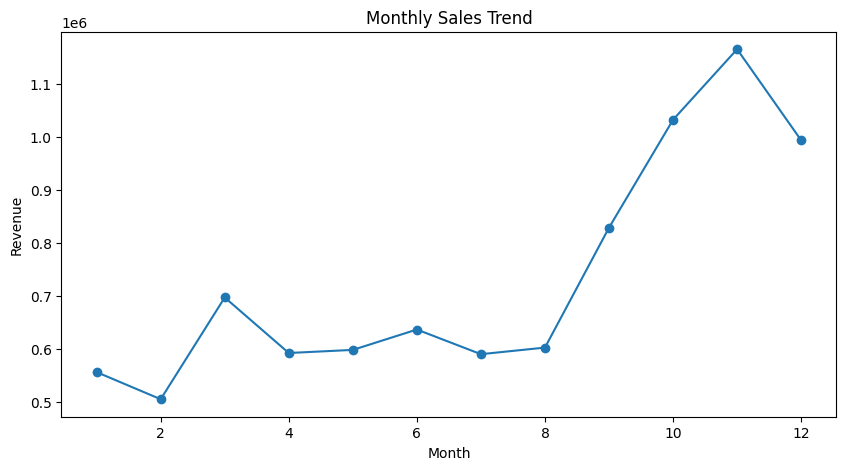

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    monthly_sales["Month"],
    monthly_sales["Revenue"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

### Monthly Sales Trend Insights
1. Revenue shows seasonal fluctuations.
2. Peak sales occur during the holiday shopping period.
3. Lower sales are observed in early-year months.

In [8]:
#top 10 countries by total_revenue
country_sales = (
    df.groupby("Country")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

country_sales

Country
United Kingdom    7381644.433
EIRE               356041.860
Netherlands        268784.350
Germany            202025.391
France             146107.070
Sweden              53147.990
Denmark             50906.850
Spain               47568.650
Switzerland         43921.390
Australia           31446.800
Name: Revenue, dtype: float64

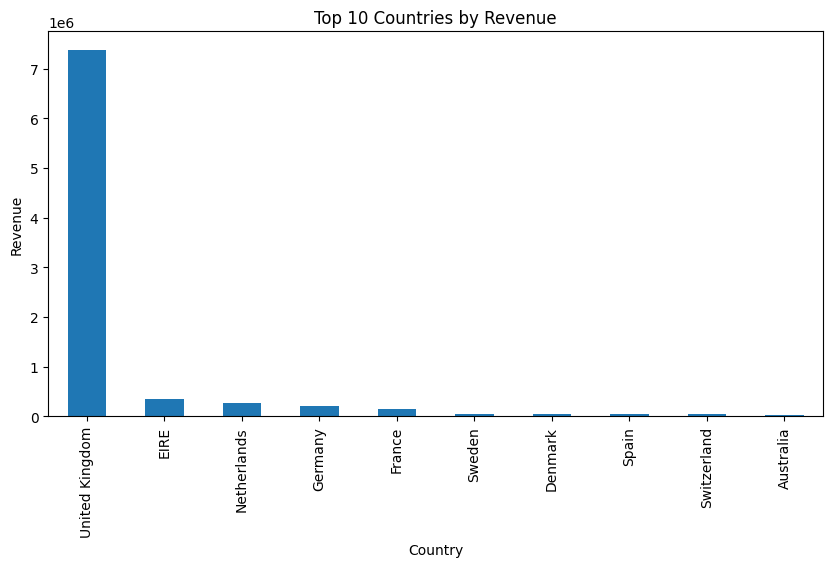

In [9]:
country_sales.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Countries by Revenue")
plt.ylabel("Revenue")
plt.show()

In [10]:
# uk contribution
uk_percentage = (
    7381644.433 /
    8798233.74
) * 100

print(uk_percentage)

83.89916261760966


## Country Sales Insights

1. The United Kingdom contributes approximately 84% of total revenue.
2. EIRE is the second-largest market.
3. European countries dominate international sales.
4. Revenue is highly concentrated in the UK market.
5. Geographic diversification opportunities exist outside the UK.

In [11]:
# Top 10 products
top_products = (
    df.groupby("Description")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_products

Description
WHITE HANGING HEART T-LIGHT HOLDER     151339.16
REGENCY CAKESTAND 3 TIER               143727.60
Manual                                  98531.99
ASSORTED COLOUR BIRD ORNAMENT           70291.03
JUMBO BAG RED RETROSPOT                 51644.25
POSTAGE                                 48741.08
ROTATING SILVER ANGELS T-LIGHT HLDR     40156.05
PAPER CHAIN KIT 50'S CHRISTMAS          36871.55
PARTY BUNTING                           35017.30
EDWARDIAN PARASOL NATURAL               34044.75
Name: Revenue, dtype: float64

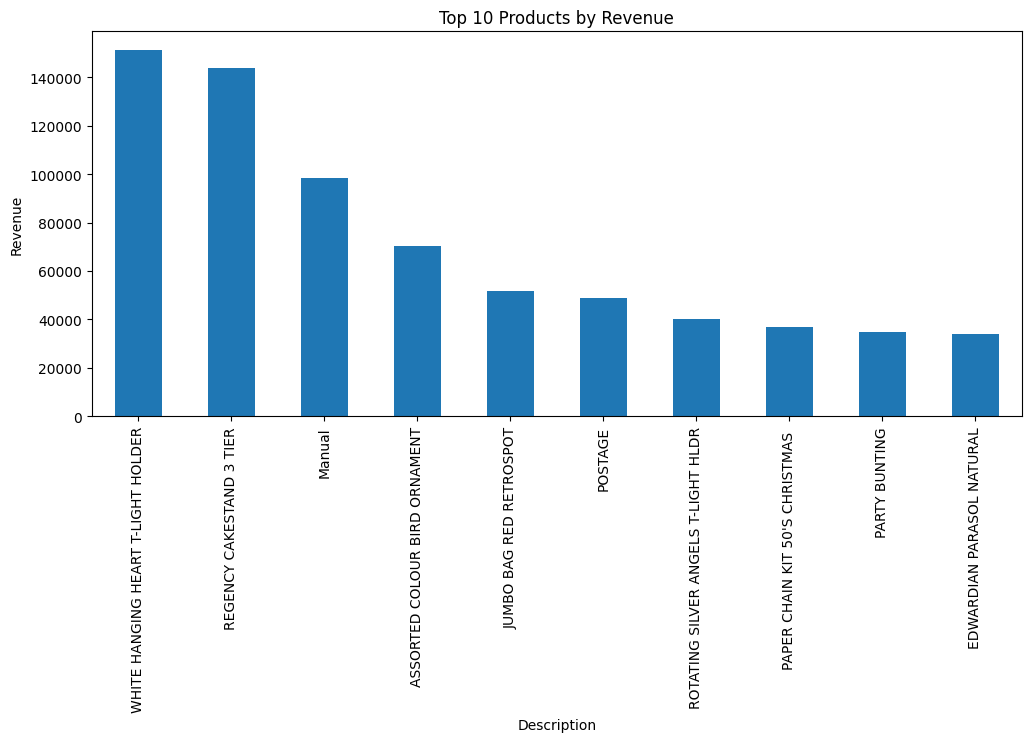

In [12]:
top_products.plot(
    kind="bar",
    figsize=(12,5)
)

plt.title("Top 10 Products by Revenue")
plt.ylabel("Revenue")
plt.show()

## Product Performance Insights

1. WHITE HANGING HEART T-LIGHT HOLDER is the highest revenue-generating product.
2. REGENCY CAKESTAND 3 TIER is the second-best performing product.
3. A small group of products contributes a significant portion of total revenue.
4. Product demand follows a Pareto-like distribution where top products drive business performance.
5. These products should be prioritized in inventory planning and promotional campaigns.

In [13]:
# Top customers
top_customers = (
    df.groupby("Customer ID")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_customers

Customer ID
18102.0    349164.35
14646.0    248396.50
14156.0    196549.74
14911.0    152121.22
13694.0    131443.19
17511.0     84541.17
15061.0     83284.38
16684.0     80489.21
16754.0     65500.07
17949.0     60117.60
Name: Revenue, dtype: float64

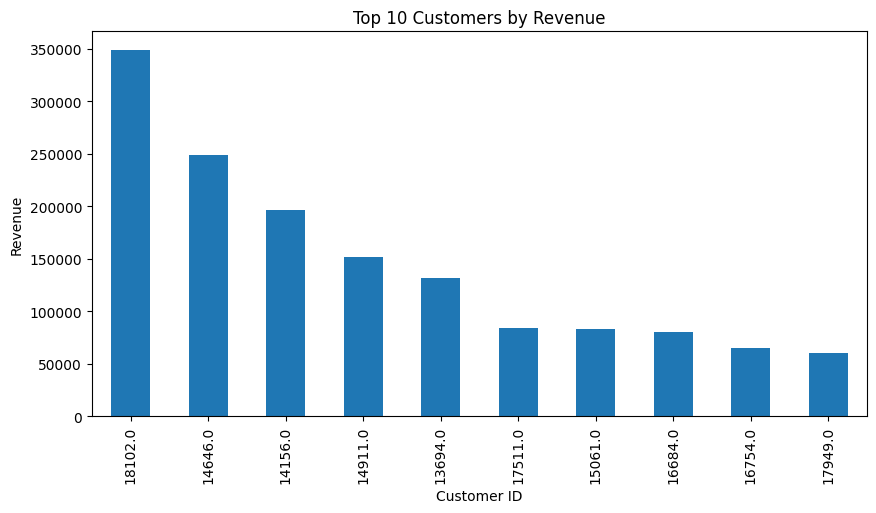

In [14]:
top_customers.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Revenue")
plt.show()

## Customer Insights

1. Revenue contribution is highly concentrated among a small number of customers.
2. Customer 18102 generated the highest revenue of approximately 349K.
3. High-value customers represent important business assets.
4. Retention strategies should focus on top-spending customers.
5. Customer segmentation can help identify VIP customers and improve marketing effectiveness.

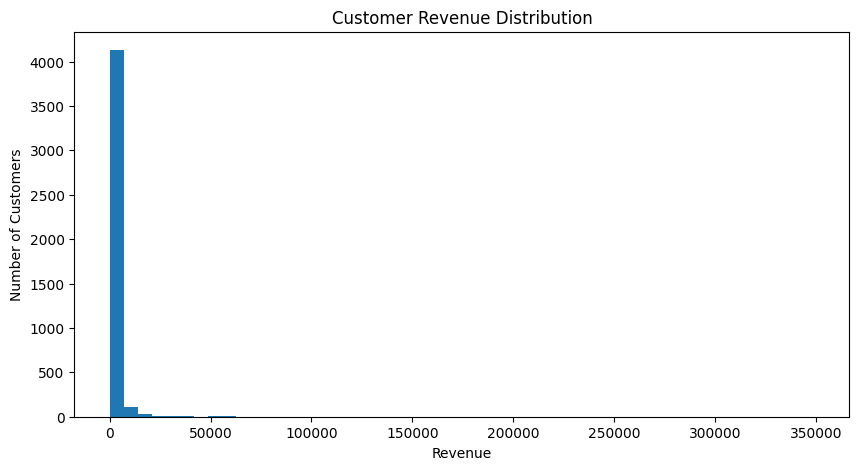

In [15]:
# Customer Revenue Distribution
customer_revenue = (
    df.groupby("Customer ID")["Revenue"]
      .sum()
)

plt.figure(figsize=(10,5))

plt.hist(
    customer_revenue,
    bins=50
)

plt.title("Customer Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Number of Customers")
plt.show()

### Customer Revenue Distribution Insight:

1. Most customers generate low-to-medium revenue.
2. A small number of VIP customers generate very high revenue.